# Classifying Planets

## Introduction

In this classification problem, we embark on a journey where we are presented with a synthetic dataset of planets and moons of our solar system. Our mission is clear: **classify from an image the planet or moon**.

In [1]:
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)


I0000 00:00:1789986211.146833   19995 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789986216.001632   19995 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789986221.560883   19995 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Set the random seed for reproducibility
seed = 5241

os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

tf.random.set_seed(seed)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

## Load the data

In [3]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "data/raw",
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128)
)

Found 1500 files belonging to 10 classes.


E0000 00:00:1789986227.033963   19995 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Exploring the data

In [4]:
print('Data shape:', dataset.element_spec[0].shape)
print('Data type:', dataset.element_spec[0].dtype)
print('Label shape:', dataset.element_spec[1].shape)
print('Label type:', dataset.element_spec[1].dtype)

labels = dataset.class_names

# Print the labels
print("Labels:")
for i, label in enumerate(labels):
    print(f"{i:4}: {label}")


Data shape: (None, 128, 128, 3)
Data type: <dtype: 'float32'>
Label shape: (None,)
Label type: <dtype: 'int32'>
Labels:
   0: Earth
   1: Jupiter
   2: Mars
   3: Mercury
   4: Moon
   5: Neptune
   6: Pluto
   7: Saturn
   8: Uranus
   9: Venus


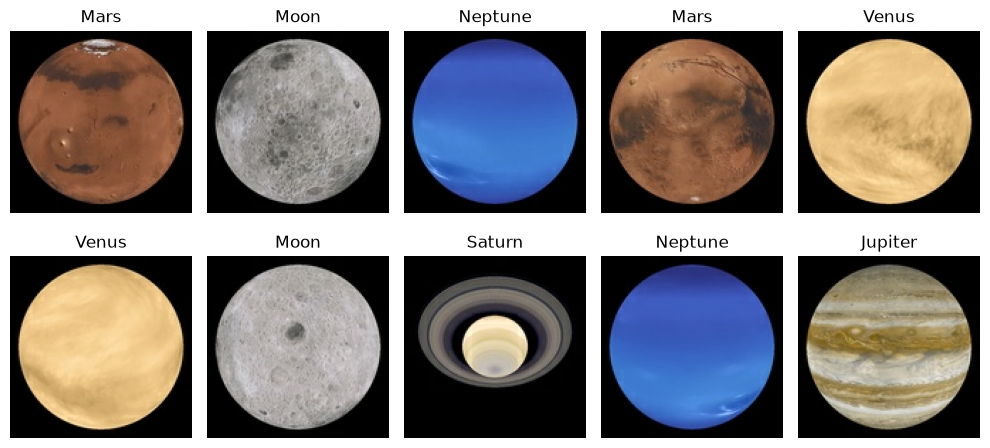

In [5]:
# Plot 10 sample images
plt.figure(figsize=(10, 5), tight_layout=True)
for images, label_idxs in dataset.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(labels[label_idxs[i].numpy()])
        plt.axis("off")

## Preparing the data

The following steps are performed to prepare the data:

- Shuffling the data
- Splitting the data into training and validation sets
- Lowering the image resolution to 32x32 pixels
- Converting images to grayscale
- Normalizing the data

These reductions make the images smaller and the model faster to train, mimicking what you would do with a larger dataset.

In [6]:
ds_train, ds_val = tf.keras.utils.image_dataset_from_directory(
    "data/raw",
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    batch_size=32,
    image_size=(32, 32),
    shuffle=True,
    seed=seed,
    validation_split=0.2,
    subset="both",
)

Found 1500 files belonging to 10 classes.
Using 1200 files for training.
Using 300 files for validation.


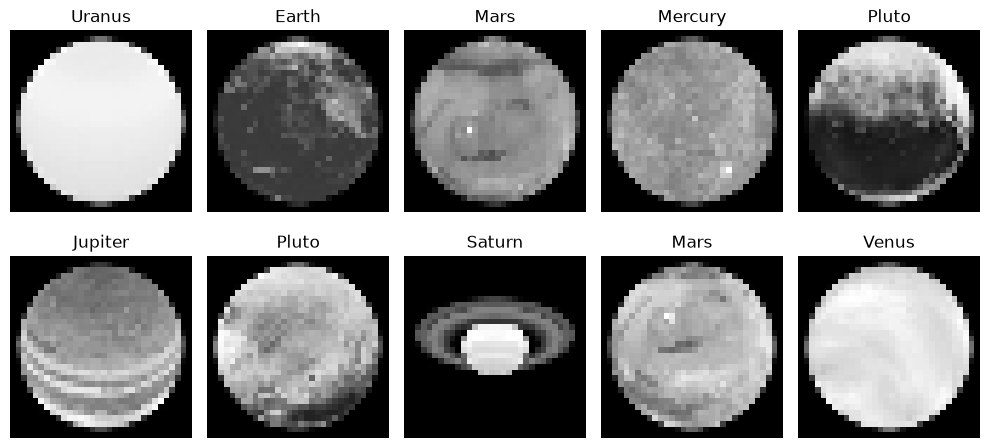

In [7]:
# Plot 10 sample images
plt.figure(figsize=(10, 5), tight_layout=True)
for images, label_idxs in ds_train.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.title(labels[label_idxs[i].numpy()])
        plt.axis("off")

In [8]:
# Normalize the data
normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255
)
ds_train = ds_train.map(lambda x, y: (normalization_layer(x), y))
ds_val = ds_val.map(lambda x, y: (normalization_layer(x), y))


## Training the model

In [9]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Input(shape=(32, 32, 1)),
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((3, 3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(len(labels)),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,834 (804.04 KB)

 Trainable params: 205,834 (804.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.fit(
    ds_train,
    epochs=5,
    validation_data=ds_val,
)

Epoch 1/5


/home/madeinshinea/Coding/master/mlops/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.2292 - sparse_categorical_accuracy: 0.1517 - val_loss: 2.1526 - val_sparse_categorical_accuracy: 0.2267
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.1441 - sparse_categorical_accuracy: 0.1983 - val_loss: 2.0747 - val_sparse_categorical_accuracy: 0.3033
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.0633 - sparse_categorical_accuracy: 0.2442 - val_loss: 1.9739 - val_sparse_categorical_accuracy: 0.2767
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.9714 - sparse_categorical_accuracy: 0.3342 - val_loss: 1.8683 - val_sparse_categorical_accuracy: 0.5800
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.8789 - sparse_categorical_accuracy: 0.4158 - val_loss: 1.7791 - val_sparse_categorical_accuracy: 0.4300


## Model Evaluation

Evaluate the model on the validation set.

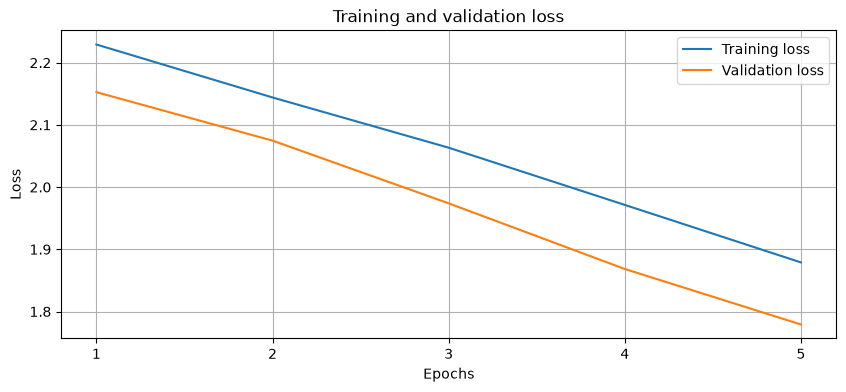

In [11]:
# Plot the training and validation loss
history = model.history.history
epochs = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs, history["loss"], label="Training loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.xticks(epochs)
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# Print validation metrics
val_loss, val_acc = model.evaluate(ds_val)
preds = model.predict(ds_val)
y_true = tf.concat([y for _, y in ds_val], axis=0).numpy()
y_pred = np.argmax(preds, axis=1)

print(f"Validation loss: {val_loss:.2f}")
print(f"Validation accuracy: {val_acc * 100:.2f}%")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.2f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.2f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='macro', zero_division=0):.2f}")
print(f"F1 score:  {f1_score(y_true, y_pred, average='macro', zero_division=0):.2f}")
print()
print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7791 - sparse_categorical_accuracy: 0.4300 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Validation loss: 1.78
Validation accuracy: 43.00%
Accuracy:  0.43
Precision: 0.31
Recall:    0.45
F1 score:  0.33

              precision    recall  f1-score   support

       Earth       0.64      1.00      0.78        23
     Jupiter       0.38      1.00      0.55        26
        Mars       0.00      0.00      0.00        34
     Mercury       0.00      0.00      0.00        29
        Moon       0.00      0.00      0.00        27
     Neptune       0.00      0.00      0.00        25
       Pluto       0.86      0.48      0.62        25
      Saturn       1.00      1.00      1.00        37
      Uranus       0.00      0.00      0.00        43
       Venus       0.22      1.00      0.36        31

    accuracy                           0.43       300
   macro avg       0.31      0.45      0.33       300
weighted avg       0.30      0.43      0.32      

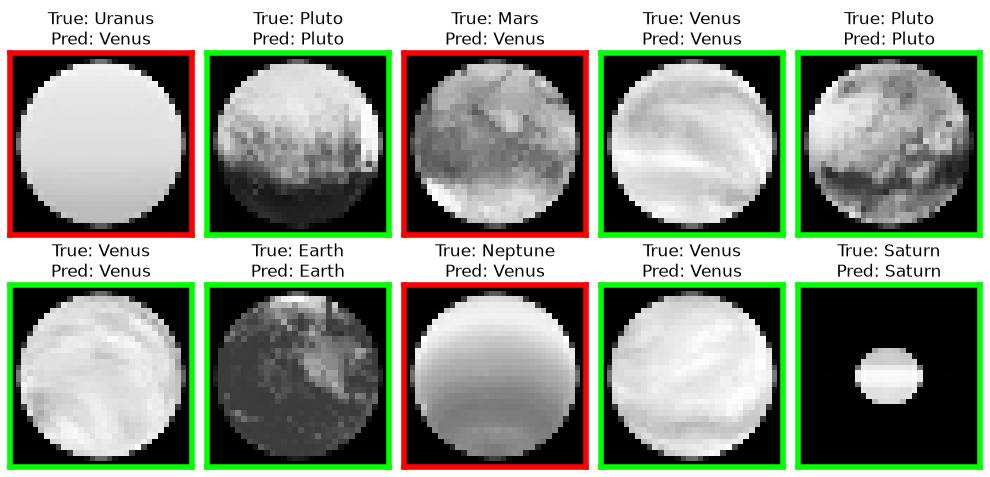

In [13]:
# Show the model's predictions on 10 random validation images
fig, axes = plt.subplots(2, 5, figsize=(10, 5), tight_layout=True)
for images, label_idxs in ds_val.take(1):
    pred_idxs = np.argmax(model.predict(images, verbose=0), axis=1)
    for ax, image, true_idx, pred_idx in zip(axes.ravel(), images, label_idxs, pred_idxs):
        true_label = labels[true_idx.numpy()]
        pred_label = labels[pred_idx]
        ax.imshow(image.numpy().squeeze(), cmap="gray")
        ax.set_title(f"True: {true_label}\nPred: {pred_label}")
        ax.set_xticks([])
        ax.set_yticks([])

        border_color = "lime" if true_idx.numpy() == pred_idx else "red"
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(4)

plt.show()


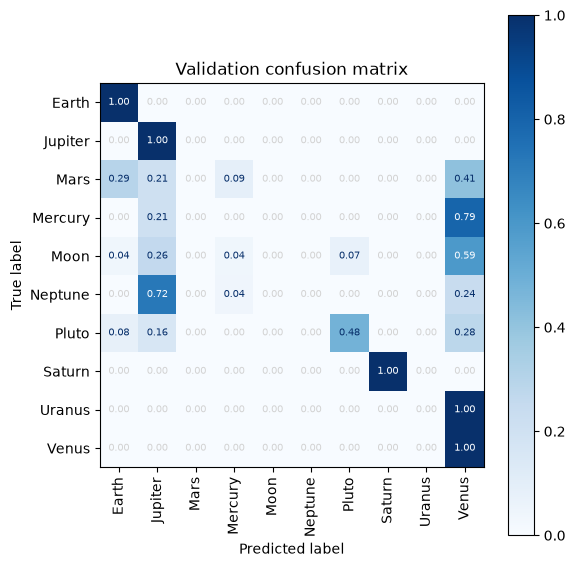

In [14]:
# Show confusion matrix of confidence per class for the validation set
fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
display = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=labels,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax,
    colorbar=True,
)

for value, text in zip(display.confusion_matrix.ravel(), display.text_.ravel()):
    text.set_fontsize(7)
    if np.isclose(value, 0.0):
        text.set_color("lightgray")

ax.set_xticklabels(labels, rotation=90)
ax.set_title("Validation confusion matrix")
plt.show()
